# Exploratory Data Analysis
This notebook provides preliminary analysis to identify useful directions before the main report.

### Notebook Overview

### Sector 1: Bi-monthly Trend
- Loads cleaned protest/riot data.
- Aggregates events in 2-month bins.
- Plots the time trend.

### Sector 2: Geographic Distribution
- Cleans coordinates and keeps valid China bounds.
- Aggregates events to admin regions for readability.
- Maps event counts (size) and event type (color).

### Sector 3: Descriptive Profiles
- Ranks months/seasons and key event fields.
- Splits and standardizes assoc_actor_1 labels.

### Sector 4: State Response Patterns
- Treats blank actor2 as no reported intervention.
- Compares intervention patterns by event form, actors, region, and crowd proxy.

### Sector 5: Intervention Strategy Composition
- Focuses on intervention-only events.
- Compares actor2 composition across key groupings with donut charts.

### Sector 6: Regional Outputs and Province Map
- Produces macro/province/city response summaries.
- Builds a province-level intervention-rate choropleth.

## Sector 1: Bi-monthly Time Trend

This section shows how protest/riot counts change over time using 2-month intervals.

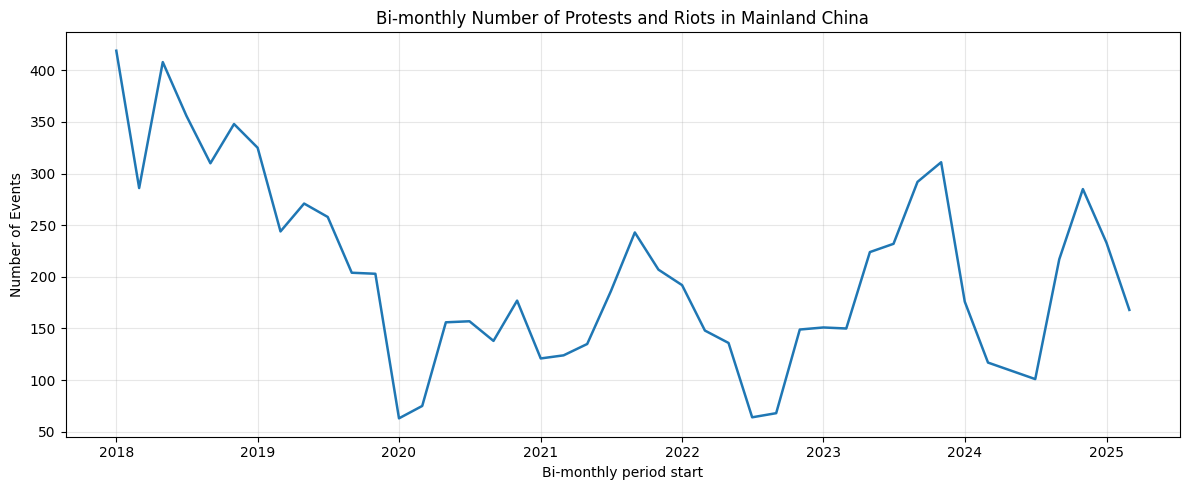

event_date
2018-01-01    419
2018-03-01    286
2018-05-01    408
2018-07-01    356
2018-09-01    310
Freq: 2MS, Name: num_events, dtype: int64

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned mainland-China dataset
df = pd.read_csv("../Data/cleaned_data.csv")

# Keep protest and riot events only (safe even if extra event types exist)
mask = df["event_type"].astype(str).str.contains("protest|riot", case=False, na=False)
df_pr = df.loc[mask].copy()

# Convert event_date to datetime and aggregate by two-month periods
df_pr["event_date"] = pd.to_datetime(df_pr["event_date"], errors="coerce")
bimonthly_counts = (
    df_pr.dropna(subset=["event_date"])
        .set_index("event_date")
        .resample("2MS")
        .size()
        .rename("num_events")
)

# Plot bi-monthly trend
plt.figure(figsize=(12, 5))
plt.plot(bimonthly_counts.index, bimonthly_counts.values, linewidth=1.8)
plt.title("Bi-monthly Number of Protests and Riots in Mainland China")
plt.xlabel("Bi-monthly period start")
plt.ylabel("Number of Events")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Optional quick preview
bimonthly_counts.head()

## Sector 2: Geographic Visualization

This section maps protest and riot events, aggregated to administrative regions for clearer patterns.

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px

# Load cleaned dataset and keep protest/riot events
df_map = pd.read_csv("../Data/cleaned_data.csv")
mask = df_map["event_type"].astype(str).str.contains("protest|riot", case=False, na=False)
map_df = df_map.loc[mask, [
    "event_type", "admin1", "admin2", "latitude", "longitude", "fatalities"
]].copy()

# Normalize event classes into two groups for coloring
event_lower = map_df["event_type"].astype(str).str.lower()
map_df["event_group"] = "Other"
map_df.loc[event_lower.str.contains("protest", na=False), "event_group"] = "Protests"
map_df.loc[event_lower.str.contains("riot", na=False), "event_group"] = "Riots"
map_df = map_df[map_df["event_group"].isin(["Protests", "Riots"])].copy()

# Clean coordinate and fatalities fields
map_df["latitude"] = pd.to_numeric(map_df["latitude"], errors="coerce")
map_df["longitude"] = pd.to_numeric(map_df["longitude"], errors="coerce")
map_df["fatalities"] = pd.to_numeric(map_df["fatalities"], errors="coerce").fillna(0)
map_df = map_df.dropna(subset=["latitude", "longitude"])
map_df = map_df[
    map_df["latitude"].between(18, 54) & map_df["longitude"].between(73, 136)
]

# Grouping rule requested by user:
# 1) Direct-administered municipalities merge by Admin1
# 2) Other places merge by Admin2 (fallback to Admin1 only when Admin2 is missing)
municipalities = {"beijing", "shanghai", "chongqing", "tianjin"}
admin1_clean = map_df["admin1"].fillna("").astype(str).str.strip()
admin2_clean = map_df["admin2"].fillna("").astype(str).str.strip()
is_municipality = admin1_clean.str.lower().isin(municipalities)
has_admin2 = admin2_clean != ""

map_df["region_key"] = np.where(
    is_municipality,
    admin1_clean,
    np.where(has_admin2, admin2_clean, admin1_clean)
)

# Aggregate to region + event_group
region_counts = (
    map_df.groupby(["region_key", "event_group"], as_index=False)
          .agg(
              num_events=("region_key", "size"),
              total_fatalities=("fatalities", "sum"),
              latitude=("latitude", "mean"),
              longitude=("longitude", "mean"),
              admin1_mode=("admin1", lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0])
          )
          .sort_values("num_events", ascending=False)
)

# Exclude low-frequency points from the map
region_counts = region_counts[region_counts["num_events"] > 4].copy()

# Proportional-symbol map: size encodes event counts; color encodes event type only
fig = px.scatter_map(
    region_counts,
    lat="latitude",
    lon="longitude",
    size="num_events",
    color="event_group",
    hover_name="region_key",
    hover_data={
        "admin1_mode": True,
        "num_events": True,
        "total_fatalities": ":.0f",
        "latitude": False,
        "longitude": False
    },
    color_discrete_map={"Protests": "#1f78b4", "Riots": "#d7301f"},
    size_max=26,
    zoom=3.2,
    center={"lat": 35, "lon": 104},
    title="Protests & Riots in China: Proportional Symbols by Administrative Region"
 )

fig.update_layout(
    map_style="carto-positron",
    height=720,
    margin={"l": 10, "r": 10, "t": 60, "b": 10},
    legend_title_text="Event Type"
)
fig.update_traces(opacity=0.68)
fig.show()

print(f"Total events mapped: {len(map_df):,}")
print(f"Number of aggregated region-type points (num_events > 2): {len(region_counts):,}")
region_counts.head(10)

Total events mapped: 8,937
Number of aggregated region-type points (num_events > 2): 274


,region_key,event_group,num_events,total_fatalities,latitude,longitude,admin1_mode
294,Shenzhen,Protests,412,0,22.562647,114.068205,Guangdong
357,Xian,Protests,377,0,34.269976,108.949371,Shaanxi
27,Beijing,Protests,339,0,39.915268,116.378541,Beijing
277,Shanghai,Protests,293,0,31.205784,121.475391,Shanghai
97,Guangzhou,Protests,278,0,23.106960,113.316989,Guangdong
420,Zhengzhou,Protests,218,0,34.731049,113.621518,Henan
345,Wuhan,Protests,199,0,30.598201,114.321116,Hubei
48,Chengdu,Protests,190,0,30.650674,104.028896,Sichuan
54,Chongqing,Protests,164,0,29.597282,106.606140,Chongqing
77,Dongwan,Protests,154,0,23.015782,113.745284,Guangdong


## Sector 3: Event and Actor Summaries

This section provides ranked descriptive statistics for timing, event types, and actor fields.

In [3]:
import pandas as pd
import re

# -----------------------------
# 1) Load and keep protest/riot events only
# -----------------------------
df_summary = pd.read_csv("../Data/cleaned_data.csv")
mask = df_summary["event_type"].astype(str).str.contains("protest|riot", case=False, na=False)
events = df_summary.loc[mask].copy()

# Parse dates once for month/season analysis
events["event_date"] = pd.to_datetime(events["event_date"], errors="coerce")
events = events.dropna(subset=["event_date"]).copy()

total_events = len(events)
print(f"Total protest/riot events used in this section: {total_events:,}")

# -----------------------------
# 2) Rank months and seasons
# -----------------------------
# Month ranking by total event count
month_rank = (
    events.assign(month=events["event_date"].dt.month_name())
          .groupby("month", as_index=False)
          .size()
          .rename(columns={"size": "num_events"})
          .sort_values("num_events", ascending=False)
          .reset_index(drop=True)
 )
month_rank["rank"] = month_rank.index + 1
month_rank["proportion"] = (month_rank["num_events"] / total_events).round(4)

# Season mapping (meteorological seasons)
month_to_season = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn"
}

season_rank = (
    events.assign(season=events["event_date"].dt.month.map(month_to_season))
          .groupby("season", as_index=False)
          .size()
          .rename(columns={"size": "num_events"})
          .sort_values("num_events", ascending=False)
          .reset_index(drop=True)
 )
season_rank["rank"] = season_rank.index + 1
season_rank["proportion"] = (season_rank["num_events"] / total_events).round(4)

print("\nSeason ranking (high to low):")
display(season_rank[["rank", "season", "num_events", "proportion"]])

print("Month ranking (high to low):")
display(month_rank[["rank", "month", "num_events", "proportion"]])

# -----------------------------
# 3) Top-10 category summaries
# -----------------------------
def normalize_assoc_actor_label(label):
    txt = str(label).strip()
    if txt == "":
        return "[Missing]"
    religious_pattern = r"christian|muslim|islam|buddhist|religious"
    ethnic_pattern = r"ethnic|tibetan|uyghur|uighur|mongol|kazakh|hui"
    if re.search(religious_pattern, txt, flags=re.IGNORECASE):
        return "Religious Groups"
    if re.search(ethnic_pattern, txt, flags=re.IGNORECASE):
        return "Ethnic Groups"
    return txt

def split_assoc_actor_1(value):
    if pd.isna(value):
        return ["[Missing]"]
    raw = str(value).strip()
    if raw == "":
        return ["[Missing]"]
    parts = [p.strip() for p in re.split(r"\s*[;:]\s*", raw) if p.strip() != ""]
    if not parts:
        return ["[Missing]"]
    out = []
    seen = set()
    for p in parts:
        norm = normalize_assoc_actor_label(p)
        if norm not in seen:
            seen.add(norm)
            out.append(norm)
    return out if out else ["[Missing]"]

def top10_with_share(frame, col_name, total_n):
    """Return top-10 count + proportion table for a categorical field."""
    s = frame[col_name].fillna("[Missing]").astype(str).str.strip()
    s = s.mask(s.eq(""), "[Missing]")

    out = (
        s.value_counts(dropna=False)
         .head(10)
         .rename_axis(col_name)
         .reset_index(name="count")
    )
    out["proportion"] = (out["count"] / total_n).round(4)
    return out

fields_to_summarize = [
    "sub_event_type",
    "actor1",
    "assoc_actor_1",
    "actor2",
    "interaction",
]

for field in fields_to_summarize:
    print(f"\nTop 10 for {field}:")
    if field == "assoc_actor_1":
        assoc_exploded = (
            events.assign(assoc_actor_1_group=events["assoc_actor_1"].apply(split_assoc_actor_1))
                  .explode("assoc_actor_1_group", ignore_index=True)
        )
        total_mentions = len(assoc_exploded)
        out = (
            assoc_exploded["assoc_actor_1_group"]
                .value_counts(dropna=False)
                .head(10)
                .rename_axis("assoc_actor_1_group")
                .reset_index(name="count")
        )
        out["proportion"] = (out["count"] / total_mentions).round(4)
        print("(Split combined entries by ';' or ':', merged Christian/Muslim into 'Religious Groups', and ethnic labels into 'Ethnic Groups')")
        print(f"Total assoc_actor_1 mentions after split: {total_mentions:,}")
        display(out)
    else:
        display(top10_with_share(events, field, total_events))

Total protest/riot events used in this section: 8,937

Season ranking (high to low):


,rank,season,num_events,proportion
0,1,Winter,2528,0.2829
1,2,Autumn,2304,0.2578
2,3,Summer,2129,0.2382
3,4,Spring,1976,0.2211


Month ranking (high to low):


,rank,month,num_events,proportion
0,1,January,1020,0.1141
1,2,December,848,0.0949
2,3,November,832,0.0931
3,4,June,775,0.0867
4,5,September,773,0.0865
5,6,October,699,0.0782
6,7,July,679,0.0760
7,8,August,675,0.0755
8,9,May,664,0.0743
9,10,February,660,0.0739



Top 10 for sub_event_type:


...

,assoc_actor_1_group,count,proportion
0,Labor Group (China),7542,0.8281
1,[Missing],850,0.0933
2,Teachers (China),198,0.0217
3,Students (China),113,0.0124
4,Farmers (China),68,0.0075
5,Former Military Forces of China (2012-),66,0.0072
6,Ethnic Groups,65,0.0071
7,Health Workers (China),60,0.0066
8,Women (China),37,0.0041
9,Religious Groups,33,0.0036



Top 10 for actor2:


,actor2,count,proportion
0,[Missing],8073,0.9033
1,Police Forces of China (2012-),595,0.0666
2,Rioters (China),121,0.0135
3,Private Security Forces (China),55,0.0062
4,Unidentified Armed Group (China),46,0.0051
5,Police Forces of China (2012-) People's Armed ...,23,0.0026
6,Civilians (China),14,0.0016
7,Unidentified Triad Group (China),9,0.0010
8,Militia (Pro-Government),1,0.0001



Top 10 for interaction:


,interaction,count,proportion
0,Protesters only,8054,0.9012
1,State forces-Protesters,463,0.0518
2,State forces-Rioters,156,0.0175
3,Rioters-Protesters,102,0.0114
4,Political militia-Protesters,54,0.0060
5,Protesters-External/Other forces,42,0.0047
6,Rioters only,19,0.0021
7,Rioters-External/Other forces,15,0.0017
8,Rioters-Rioters,15,0.0017
9,Rioters-Civilians,14,0.0016


## State Response Summary

This section treats state response as actor2 content, where missing values indicate no reported intervention.

It summarizes response patterns by:
- Event form (protest vs riot)
- Associated actor groups (assoc_actor_1)
- Geography (macro-region, province, city)
- Crowd-size proxy from tags
- Xinjiang and Tibet focus

Notes:
- Combined assoc_actor_1 values are split into separate groups.
- Christian/Muslim labels are merged into Religious Groups.
- Ethnic labels are merged into Ethnic Groups.
- Macro-regions use a simplified North/East/South/West coding.
- Results are descriptive, not causal.

In [4]:
import pandas as pd
import numpy as np
import re

# -----------------------------
# 1) Prepare analysis dataset
# -----------------------------
df_state = pd.read_csv("../Data/cleaned_data.csv")
mask = df_state["event_type"].astype(str).str.contains("protest|riot", case=False, na=False)
state = df_state.loc[mask].copy()

# Broad event form: riot vs protest
etype = state["event_type"].astype(str).str.lower()
state["event_form"] = np.where(etype.str.contains("riot", na=False), "Riot", "Protest")

def normalize_assoc_actor_label(label):
    txt = str(label).strip()
    if txt == "":
        return "[Missing]"
    religious_pattern = r"christian|muslim|islam|religio"
    ethnic_pattern = r"ethnic|tibetan|uyghur|uighur|mongol|kazakh|hui"
    if re.search(religious_pattern, txt, flags=re.IGNORECASE):
        return "Religious Groups"
    if re.search(ethnic_pattern, txt, flags=re.IGNORECASE):
        return "Ethnic Groups"
    return txt

def split_assoc_actor_1(value):
    if pd.isna(value):
        return ["[Missing]"]
    raw = str(value).strip()
    if raw == "":
        return ["[Missing]"]
    parts = [p.strip() for p in re.split(r"\s*[;:]\s*", raw) if p.strip() != ""]
    if not parts:
        return ["[Missing]"]
    out = []
    seen = set()
    for p in parts:
        norm = normalize_assoc_actor_label(p)
        if norm not in seen:
            seen.add(norm)
            out.append(norm)
    return out if out else ["[Missing]"]

# Normalize key fields
state["province"] = state["admin1"].fillna("[Missing]").astype(str).str.strip().replace("", "[Missing]")
state["city"] = state["admin2"].fillna("").astype(str).str.strip()
state["city"] = np.where(state["city"] == "", state["province"], state["city"] )
state["assoc_groups_list"] = state["assoc_actor_1"].apply(split_assoc_actor_1)

# Intervention definition: any event with non-blank actor2
state["actor2_clean"] = state["actor2"].fillna("").astype(str).str.strip()
state["intervention_reported"] = state["actor2_clean"].ne("")
state.loc[state["actor2_clean"] == "", "actor2_clean"] = "[No reported intervention]"

# A stricter indicator for coercive/security response in actor2
security_keywords = "Police Forces|People's Armed Police|Private Security|Militia|State forces|Armed"
state["security_response"] = state["actor2_clean"].str.contains(security_keywords, case=False, na=False)

# Crowd-size proxy from tags (keyword-based proxy)
tags_txt = state["tags"].fillna("").astype(str).str.lower()
large_kw = "large|mass|thousand|thousands|hundred|hundreds"
small_kw = "small|few|dozen|dozens"
state["crowd_size_proxy"] = "Unknown/Not stated"
state.loc[tags_txt.str.contains(large_kw, na=False), "crowd_size_proxy"] = "Large crowd (proxy)"
state.loc[tags_txt.str.contains(small_kw, na=False), "crowd_size_proxy"] = "Small crowd (proxy)"

# Simplified macro-region coding (four-way)
macro_map = {
    "Beijing": "North", "Tianjin": "North", "Hebei": "North", "Shanxi": "North",
    "Inner Mongolia": "North", "Liaoning": "North", "Jilin": "North", "Heilongjiang": "North",
    "Shanghai": "East", "Jiangsu": "East", "Zhejiang": "East", "Anhui": "East",
    "Fujian": "East", "Jiangxi": "East", "Shandong": "East",
    "Henan": "South", "Hubei": "South", "Hunan": "South", "Guangdong": "South",
    "Guangxi": "South", "Hainan": "South",
    "Chongqing": "West", "Sichuan": "West", "Guizhou": "West", "Yunnan": "West",
    "Tibet": "West", "Shaanxi": "West", "Gansu": "West", "Qinghai": "West",
    "Ningxia": "West", "Xinjiang": "West"
}
state["macro_region"] = state["province"].map(macro_map).fillna("West")

total_n = len(state)
print(f"Total protest/riot events in this section: {total_n:,}")

# Helper to summarize response rates by any grouping variable.
def response_summary(frame, group_col):
    out = (
        frame.groupby(group_col, as_index=False)
             .agg(
                 n_events=("actor2_clean", "size"),
                 intervention_rate=("intervention_reported", "mean"),
                 no_intervention_rate=("intervention_reported", lambda s: 1 - s.mean()),
                 security_response_rate=("security_response", "mean")
             )
    )
    for c in ["intervention_rate", "no_intervention_rate", "security_response_rate"]:
        out[c] = (out[c] * 100).round(2)
    out = out.sort_values(["intervention_rate", "security_response_rate", "n_events"], ascending=[False, False, False])
    return out.reset_index(drop=True)

# -----------------------------
# 2) Event form (Protest vs Riot)
# -----------------------------
print("\nA) State response by event form (Protest vs Riot):")
display(response_summary(state, "event_form"))

print("Top actor2 categories within each event form (top 10):")
for form in ["Protest", "Riot"]:
    sub = state[state["event_form"] == form]
    top_actor2 = (
        sub["actor2_clean"].value_counts().head(10)
           .rename_axis("actor2")
           .reset_index(name="count")
    )
    top_actor2["proportion_%"] = (top_actor2["count"] / len(sub) * 100).round(2)
    top_actor2 = top_actor2.sort_values(["proportion_%", "count"], ascending=[False, False]).reset_index(drop=True)
    print(f"\n{form}:")
    display(top_actor2)

# -----------------------------
# 3) Associated actors (assoc_actor_1, split + recoded)
# -----------------------------
state_assoc = state.explode("assoc_groups_list", ignore_index=True).rename(columns={"assoc_groups_list": "assoc_group_norm"})
print("\nB) State response by associated actor group (split combinations, Religious Groups merged, Ethnic Groups merged; top 15 by frequency):")
top_assoc = state_assoc["assoc_group_norm"].value_counts().head(15).index
assoc_summary = response_summary(state_assoc[state_assoc["assoc_group_norm"].isin(top_assoc)], "assoc_group_norm")
display(assoc_summary)

# -----------------------------
# 4) Crowd-size summary
# -----------------------------
print("\nC) State response by crowd-size proxy (from tags):")
crowd_summary = response_summary(state, "crowd_size_proxy")
display(crowd_summary)

# -----------------------------
# 5) Xinjiang & Tibet focus
# -----------------------------
focus_provinces = ["Xinjiang", "Tibet"]
state["focus_region"] = np.where(state["province"].isin(focus_provinces), state["province"], "Other provinces")

print("\nD) Xinjiang/Tibet vs others (ordered by proportion):")
focus_summary = response_summary(state, "focus_region")
display(focus_summary)

print("Top actor2 categories in Xinjiang and Tibet:")
for prov in focus_provinces:
    sub = state[state["province"] == prov]
    if len(sub) == 0:
        print(f"\n{prov}: no events in current cleaned dataset.")
        continue
    top_actor2 = (
        sub["actor2_clean"].value_counts().head(10)
           .rename_axis("actor2")
           .reset_index(name="count")
    )
    top_actor2["proportion_%"] = (top_actor2["count"] / len(sub) * 100).round(2)
    top_actor2 = top_actor2.sort_values(["proportion_%", "count"], ascending=[False, False]).reset_index(drop=True)
    print(f"\n{prov} (n={len(sub)}):")
    display(top_actor2)

Total protest/riot events in this section: 8,937

A) State response by event form (Protest vs Riot):


,event_form,n_events,intervention_rate,no_intervention_rate,security_response_rate
0,Riot,222,91.44,8.56,76.13
1,Protest,8715,7.58,92.42,6.32


Top actor2 categories within each event form (top 10):

Protest:


,actor2,count,proportion_%
0,[No reported intervention],8054,92.42
1,Police Forces of China (2012-),454,5.21
2,Rioters (China),102,1.17
3,Unidentified Armed Group (China),45,0.52
4,Private Security Forces (China),42,0.48
5,Police Forces of China (2012-) People's Armed ...,9,0.10
6,Unidentified Triad Group (China),8,0.09
7,Militia (Pro-Government),1,0.01



Riot:


...

,focus_region,n_events,intervention_rate,no_intervention_rate,security_response_rate
0,Tibet,18,22.22,77.78,22.22
1,Other provinces,8847,9.68,90.32,8.06
2,Xinjiang,72,5.56,94.44,4.17


Top actor2 categories in Xinjiang and Tibet:

Xinjiang (n=72):


,actor2,count,proportion_%
0,[No reported intervention],68,94.44
1,Police Forces of China (2012-),3,4.17
2,Rioters (China),1,1.39



Tibet (n=18):


,actor2,count,proportion_%
0,[No reported intervention],14,77.78
1,Police Forces of China (2012-),4,22.22


## How Are Interventions Used Differently?

In [5]:
import pandas as pd
import numpy as np
import re
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# -------------------------------------------------------------
# Cell 8: Intervention-only actor2 strategy profile (readable)
# -------------------------------------------------------------

def short_label(txt, max_len=28):
    txt = str(txt)
    return txt if len(txt) <= max_len else txt[: max_len - 1] + "..."

def normalize_assoc_actor_label(label):
    txt = str(label).strip()
    if txt == "":
        return "[Missing]"
    religious_pattern = r"christian|muslim|islam|religio"
    ethnic_pattern = r"ethnic|tibetan|uyghur|uighur|mongol|kazakh|hui"
    if re.search(religious_pattern, txt, flags=re.IGNORECASE):
        return "Religious Groups"
    if re.search(ethnic_pattern, txt, flags=re.IGNORECASE):
        return "Ethnic Groups"
    return txt

def split_assoc_actor_1(value):
    if pd.isna(value):
        return ["[Missing]"]
    raw = str(value).strip()
    if raw == "":
        return ["[Missing]"]
    parts = [p.strip() for p in re.split(r"\s*[;:]\s*", raw) if p.strip() != ""]
    if not parts:
        return ["[Missing]"]
    out = []
    seen = set()
    for p in parts:
        norm = normalize_assoc_actor_label(p)
        if norm not in seen:
            seen.add(norm)
            out.append(norm)
    return out if out else ["[Missing]"]

# Build/reuse analysis frame
if "state" not in globals():
    df_state = pd.read_csv("../Data/cleaned_data.csv")
    mask = df_state["event_type"].astype(str).str.contains("protest|riot", case=False, na=False)
    state = df_state.loc[mask].copy()

    etype = state["event_type"].astype(str).str.lower()
    state["event_form"] = np.where(etype.str.contains("riot", na=False), "Riot", "Protest")

    state["province"] = state["admin1"].fillna("[Missing]").astype(str).str.strip().replace("", "[Missing]")
    state["assoc_groups_list"] = state["assoc_actor_1"].apply(split_assoc_actor_1)
else:
    if "assoc_groups_list" not in state.columns:
        state["assoc_groups_list"] = state["assoc_actor_1"].apply(split_assoc_actor_1)

# Intervention definition: any event with non-blank actor2
state["actor2_clean"] = state["actor2"].fillna("").astype(str).str.strip()
state["intervention_reported"] = state["actor2_clean"].ne("")
state.loc[state["actor2_clean"] == "", "actor2_clean"] = "[No reported intervention]"

# Crowd-size proxy from tags (keyword-based; descriptive proxy)
tags_txt = state["tags"].fillna("").astype(str).str.lower()
large_kw = "large|mass|thousand|thousands|hundred|hundreds"
small_kw = "small|few|dozen|dozens"
state["crowd_size_proxy"] = "Unknown/Not stated"
state.loc[tags_txt.str.contains(large_kw, na=False), "crowd_size_proxy"] = "Large crowd (proxy)"
state.loc[tags_txt.str.contains(small_kw, na=False), "crowd_size_proxy"] = "Small crowd (proxy)"

# Keep ONLY events with reported intervention
interv = state[state["intervention_reported"]].copy()
print(f"Intervention events used in Cell 8: {len(interv):,}")

def top_actor2_table(frame, group_col, top_groups=4, top_actor2=6):
    groups = frame[group_col].value_counts().head(top_groups).index.tolist()
    out_list = []
    for g in groups:
        sub = frame[frame[group_col] == g]
        tab = sub["actor2_clean"].value_counts().head(top_actor2).reset_index()
        tab.columns = ["actor2", "count"]
        tab["proportion_%"] = (tab["count"] / tab["count"].sum() * 100).round(2)
        tab[group_col] = g
        out_list.append(tab)
    if not out_list:
        return pd.DataFrame(columns=[group_col, "actor2", "count", "proportion_%"]), []
    out = pd.concat(out_list, ignore_index=True)
    out = out.sort_values([group_col, "proportion_%", "count"], ascending=[True, False, False])
    return out[[group_col, "actor2", "count", "proportion_%"]], groups

def donut_subplots(frame, group_col, groups, title, top_actor2=6):
    if not groups:
        print(f"No groups available for {group_col}")
        return
    n = len(groups)
    cols = 2 if n > 1 else 1
    rows = (n + cols - 1) // cols
    specs = [[{"type": "domain"} for _ in range(cols)] for _ in range(rows)]
    subplot_titles = [short_label(g, 26) for g in groups] + [""] * (rows * cols - n)

    fig = make_subplots(rows=rows, cols=cols, specs=specs, subplot_titles=subplot_titles)
    for idx, g in enumerate(groups):
        r = idx // cols + 1
        c = idx % cols + 1
        sub = frame[frame[group_col] == g]
        vc = sub["actor2_clean"].value_counts()
        top = vc.head(top_actor2).index
        labels = sub["actor2_clean"].where(sub["actor2_clean"].isin(top), "Other")
        pie = labels.value_counts().reset_index()
        pie.columns = ["actor2_group", "count"]

        fig.add_trace(
            go.Pie(
                labels=pie["actor2_group"],
                values=pie["count"],
                hole=0.5,
                sort=False,
                textinfo="none",
                textposition="none",
                hovertemplate="actor2=%{label}<br>count=%{value}<br>share=%{percent}<extra></extra>"
            ),
            row=r, col=c
        )

    fig.update_layout(
        title=title,
        height=420 * rows,
        legend_title_text="Actor2 type",
        legend=dict(orientation="h", yanchor="top", y=-0.05, x=0),
        margin={"l": 10, "r": 10, "t": 70, "b": 70}
    )
    fig.update_annotations(font=dict(size=12))
    fig.show()

# A) Protest vs Riot
table_form, form_groups = top_actor2_table(interv, "event_form", top_groups=2, top_actor2=8)
print("\nA) Actor2 composition among intervention events: Protest vs Riot")
display(table_form)
donut_subplots(interv, "event_form", form_groups, "Actor2 Composition (Intervention Events): Protest vs Riot", top_actor2=8)

# D) Crowd-size proxy from tags
crowd_order = ["Large crowd (proxy)", "Small crowd (proxy)", "Unknown/Not stated"]
interv_crowd = interv.copy()
interv_crowd["crowd_size_proxy"] = pd.Categorical(interv_crowd["crowd_size_proxy"], categories=crowd_order, ordered=True)

table_crowd, _ = top_actor2_table(interv_crowd, "crowd_size_proxy", top_groups=3, top_actor2=6)
table_crowd["crowd_size_proxy"] = pd.Categorical(table_crowd["crowd_size_proxy"], categories=crowd_order, ordered=True)
table_crowd = table_crowd.sort_values(["crowd_size_proxy", "proportion_%", "count"], ascending=[True, False, False])

print("\nD) Actor2 composition among intervention events: Crowd-size proxy (from tags)")
display(table_crowd)
donut_subplots(interv_crowd, "crowd_size_proxy", crowd_order, "Actor2 Composition (Intervention Events): Crowd-size Proxy", top_actor2=6)

Intervention events used in Cell 8: 864

A) Actor2 composition among intervention events: Protest vs Riot


,event_form,actor2,count,proportion_%
0,Protest,Police Forces of China (2012-),454,68.68
1,Protest,Rioters (China),102,15.43
2,Protest,Unidentified Armed Group (China),45,6.81
3,Protest,Private Security Forces (China),42,6.35
4,Protest,Police Forces of China (2012-) People's Armed ...,9,1.36
5,Protest,Unidentified Triad Group (China),8,1.21
6,Protest,Militia (Pro-Government),1,0.15
7,Riot,Police Forces of China (2012-),141,69.46
8,Riot,Rioters (China),19,9.36
9,Riot,Civilians (China),14,6.90



D) Actor2 composition among intervention events: Crowd-size proxy (from tags)


,crowd_size_proxy,actor2,count,proportion_%
12,Large crowd (proxy),Police Forces of China (2012-),58,85.29
13,Large crowd (proxy),Police Forces of China (2012-) People's Armed ...,4,5.88
14,Large crowd (proxy),Rioters (China),3,4.41
15,Large crowd (proxy),Private Security Forces (China),1,1.47
16,Large crowd (proxy),Unidentified Armed Group (China),1,1.47
17,Large crowd (proxy),Civilians (China),1,1.47
6,Small crowd (proxy),Police Forces of China (2012-),56,82.35
7,Small crowd (proxy),Rioters (China),5,7.35
8,Small crowd (proxy),Private Security Forces (China),3,4.41
9,Small crowd (proxy),Unidentified Armed Group (China),2,2.94


## Detailed Actor2 Composition (Readable Donut Charts)

These charts are formatted for readability:
- No in-slice percentage labels
- No percentage callout lines
- Short subplot titles
- Exact values shown in legend and hover

They summarize actor2 composition across event form, associated actor groups, and macro-regions.

In [6]:
import pandas as pd
import re
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Legacy figure cell, reformatted for readability and recoded assoc_actor_1 handling
def normalize_assoc_actor_label(label):
    txt = str(label).strip()
    if txt == "":
        return "[Missing]"
    religious_pattern = r"christian|muslim|islam|religio"
    ethnic_pattern = r"ethnic|tibetan|uyghur|uighur|mongol|kazakh|hui"
    if re.search(religious_pattern, txt, flags=re.IGNORECASE):
        return "Religious Groups"
    if re.search(ethnic_pattern, txt, flags=re.IGNORECASE):
        return "Ethnic Groups"
    return txt

def split_assoc_actor_1(value):
    if pd.isna(value):
        return ["[Missing]"]
    raw = str(value).strip()
    if raw == "":
        return ["[Missing]"]
    parts = [p.strip() for p in re.split(r"\s*[;:]\s*", raw) if p.strip() != ""]
    if not parts:
        return ["[Missing]"]
    out = []
    seen = set()
    for p in parts:
        norm = normalize_assoc_actor_label(p)
        if norm not in seen:
            seen.add(norm)
            out.append(norm)
    return out if out else ["[Missing]"]

if "state" not in globals():
    df_state = pd.read_csv("../Data/cleaned_data.csv")
    mask = df_state["event_type"].astype(str).str.contains("protest|riot", case=False, na=False)
    state = df_state.loc[mask].copy()
    etype = state["event_type"].astype(str).str.lower()
    state["event_form"] = etype.map(lambda x: "Riot" if "riot" in x else "Protest")
    state["province"] = state["admin1"].fillna("[Missing]").astype(str).str.strip().replace("", "[Missing]")
    macro_map = {
        "Beijing": "North", "Tianjin": "North", "Hebei": "North", "Shanxi": "North",
        "Inner Mongolia": "North", "Liaoning": "North", "Jilin": "North", "Heilongjiang": "North",
        "Shanghai": "East", "Jiangsu": "East", "Zhejiang": "East", "Anhui": "East",
        "Fujian": "East", "Jiangxi": "East", "Shandong": "East",
        "Henan": "South", "Hubei": "South", "Hunan": "South", "Guangdong": "South",
        "Guangxi": "South", "Hainan": "South",
        "Chongqing": "West", "Sichuan": "West", "Guizhou": "West", "Yunnan": "West",
        "Tibet": "West", "Shaanxi": "West", "Gansu": "West", "Qinghai": "West",
        "Ningxia": "West", "Xinjiang": "West"
    }
    state["macro_region"] = state["province"].map(macro_map).fillna("West")
    state["actor2_clean"] = state["actor2"].fillna("[No reported intervention]").astype(str).str.strip()
    state.loc[state["actor2_clean"] == "", "actor2_clean"] = "[No reported intervention]"

state["assoc_groups_list"] = state["assoc_actor_1"].apply(split_assoc_actor_1)

def short_label(txt, max_len=28):
    txt = str(txt)
    return txt if len(txt) <= max_len else txt[: max_len - 1] + "..."

def collapse_actor2(frame, top_n=6):
    vc = frame["actor2_clean"].value_counts()
    top = vc.head(top_n).index
    labels = frame["actor2_clean"].where(frame["actor2_clean"].isin(top), "Other")
    out = labels.value_counts().reset_index()
    out.columns = ["actor2_group", "count"]
    return out

def rank_groups_by_non_intervention(frame, group_col, groups):
    valid_groups = [g for g in groups if str(g).strip() != "[Missing]"]
    if not valid_groups:
        return []
    sub = frame[frame[group_col].isin(valid_groups)].copy()
    rates = (
        sub.assign(non_intervention=sub["actor2_clean"].eq("[No reported intervention]"))
           .groupby(group_col, as_index=False)
           .agg(non_intervention_rate=("non_intervention", "mean"), n=("actor2_clean", "size"))
           .sort_values(["non_intervention_rate", "n"], ascending=[False, False])
    )
    return rates[group_col].tolist()

def readable_donuts(frame, group_col, groups, title, top_n=6):
    groups = rank_groups_by_non_intervention(frame, group_col, groups)
    if not groups:
        print(f"No groups available for {group_col}")
        return

    cols = 3 if len(groups) > 1 else 1
    rows = (len(groups) + cols - 1) // cols
    specs = [[{"type": "domain"} for _ in range(cols)] for _ in range(rows)]
    subplot_titles = [short_label(g, 26) for g in groups] + [""] * (rows * cols - len(groups))
    fig = make_subplots(rows=rows, cols=cols, specs=specs, subplot_titles=subplot_titles)

    for i, g in enumerate(groups):
        r = i // cols + 1
        c = i % cols + 1
        sub = frame[frame[group_col] == g]
        pie_df = collapse_actor2(sub, top_n=top_n)
        fig.add_trace(
            go.Pie(
                labels=pie_df["actor2_group"],
                values=pie_df["count"],
                hole=0.5,
                sort=False,
                textinfo="none",
                textposition="none",
                hovertemplate="actor2=%{label}<br>count=%{value}<br>share=%{percent}<extra></extra>"
            ),
            row=r, col=c
        )

    # Reduce donut radius by 30% by shrinking each pie trace domain around its center.
    scale = 0.7
    for tr in fig.data:
        if isinstance(tr, go.Pie) and tr.domain is not None:
            x0, x1 = tr.domain.x
            y0, y1 = tr.domain.y
            x_mid = (x0 + x1) / 2
            y_mid = (y0 + y1) / 2
            x_half = (x1 - x0) * scale / 2
            y_half = (y1 - y0) * scale / 2
            tr.domain.x = [x_mid - x_half, x_mid + x_half]
            tr.domain.y = [y_mid - y_half, y_mid + y_half]

    fig.update_layout(
        title=title,
        height=360 * rows,
        legend_title_text="Actor2 type",
        legend=dict(orientation="h", yanchor="top", y=-0.08, x=0),
        margin={"l": 10, "r": 10, "t": 70, "b": 80}
    )
    fig.update_annotations(font=dict(size=11))
    fig.show()

# 1) Event form
readable_donuts(state, "event_form", ["Protest", "Riot"], "Actor2 Composition by Event Form (Ranked by Non-Intervention Rate)", top_n=6)

# 2) Top associated actor groups (split + recoded assoc_actor_1)
state_assoc = state.explode("assoc_groups_list", ignore_index=True).rename(columns={"assoc_groups_list": "assoc_group_norm"})
top_assoc_groups = (
    state_assoc["assoc_group_norm"]
    .value_counts()
    .drop(labels=["[Missing]"], errors="ignore")
    .head(10)
    .index
    .tolist()
)
readable_donuts(
    state_assoc,
    "assoc_group_norm",
    top_assoc_groups,
    "Actor2 Composition by Top 10 assoc_actor_1 Groups (Ranked by Non-Intervention Rate)",
    top_n=6,
)

# 3) Macro-region
# macro_regions = ["North", "East", "South", "West"]
# readable_donuts(state[state["macro_region"].isin(macro_regions)], "macro_region", macro_regions, "Actor2 Composition by Macro-Region", top_n=6)

print("Readable donut charts generated (ranked by non-intervention rate; [Missing] group excluded).")

Readable donut charts generated (ranked by non-intervention rate; [Missing] group excluded).


In [7]:
import pandas as pd
import plotly.express as px
import json
from urllib.request import urlopen

# -------------------------------------------------------------
# Cell 13: Regional summaries moved from Cell 8 + province map
# -------------------------------------------------------------

if "state" not in globals() or "response_summary" not in globals():
    raise RuntimeError("Please run Cell 8 first to create 'state' and 'response_summary'.")

print("A) State response by macro-region (North/East/South/West):")
macro_summary = response_summary(state, "macro_region")
display(macro_summary)

print("\nB) State response by province (top 20 by events, ordered by proportion):")
prov_summary = response_summary(state, "province").head(20)
display(prov_summary)

print("\nC) State response by city (top 20 by events, ordered by proportion; n_events >= 10):")
city_summary = response_summary(state, "city")
city_summary = city_summary[city_summary["n_events"] >= 10].head(20)
display(city_summary)

# Province-level intervention choropleth with provincial borders
province_name_map = {
    "Beijing": "北京市",
    "Tianjin": "天津市",
    "Hebei": "河北省",
    "Shanxi": "山西省",
    "Inner Mongolia": "内蒙古自治区",
    "Liaoning": "辽宁省",
    "Jilin": "吉林省",
    "Heilongjiang": "黑龙江省",
    "Shanghai": "上海市",
    "Jiangsu": "江苏省",
    "Zhejiang": "浙江省",
    "Anhui": "安徽省",
    "Fujian": "福建省",
    "Jiangxi": "江西省",
    "Shandong": "山东省",
    "Henan": "河南省",
    "Hubei": "湖北省",
    "Hunan": "湖南省",
    "Guangdong": "广东省",
    "Guangxi": "广西壮族自治区",
    "Hainan": "海南省",
    "Chongqing": "重庆市",
    "Sichuan": "四川省",
    "Guizhou": "贵州省",
    "Yunnan": "云南省",
    "Tibet": "西藏自治区",
    "Shaanxi": "陕西省",
    "Gansu": "甘肃省",
    "Qinghai": "青海省",
    "Ningxia": "宁夏回族自治区",
    "Xinjiang": "新疆维吾尔自治区"
}

prov_geo = (
    state.groupby("province", as_index=False)
         .agg(
             n_events=("province", "size"),
             intervention_rate=("intervention_reported", "mean")
         )
)
prov_geo["intervention_rate_pct"] = (prov_geo["intervention_rate"] * 100).round(2)
prov_geo["province_cn"] = prov_geo["province"].map(province_name_map)
prov_geo = prov_geo.dropna(subset=["province_cn"]).copy()

geojson_url = "https://raw.githubusercontent.com/longwosion/geojson-map-china/master/china.json"
with urlopen(geojson_url) as response:
    china_geojson = json.load(response)

# Keep mainland provincial units only (exclude HK/Macau/Taiwan to match cleaned dataset)
exclude_names = {"香港特别行政区", "澳门特别行政区", "台湾省"}
china_geojson["features"] = [
    f for f in china_geojson["features"]
    if f.get("properties", {}).get("name") not in exclude_names
]

# Single-hue (orange) scale: darker = higher, with a visible light end on gray basemap
single_hue_scale = [
    [0.0, "#fdd0a2"],
    [0.25, "#fdae6b"],
    [0.5, "#fd8d3c"],
    [0.75, "#e6550d"],
    [1.0, "#a63603"]
]

fig = px.choropleth_map(
    prov_geo,
    geojson=china_geojson,
    locations="province_cn",
    featureidkey="properties.name",
    color="intervention_rate_pct",
    color_continuous_scale=single_hue_scale,
    center={"lat": 35, "lon": 104},
    zoom=3.15,
    opacity=0.9,
    hover_name="province",
    hover_data={
        "province_cn": False,
        "n_events": True,
        "intervention_rate_pct": ":.2f"
    },
    title="Province-Level Intervention Rate in China (Filled Provinces)"
 )

fig.update_traces(
    marker_line_color="#2f2f2f",
    marker_line_width=0.8
)
fig.update_layout(
    map_style="carto-positron",
    height=760,
    margin={"l": 10, "r": 10, "t": 70, "b": 10},
    coloraxis_colorbar=dict(title="Intervention rate (%)")
)
fig.show()

print(f"Mapped provinces: {len(prov_geo):,}")

A) State response by macro-region (North/East/South/West):


,macro_region,n_events,intervention_rate,no_intervention_rate,security_response_rate
0,South,2991,10.77,89.23,9.06
1,North,1754,9.64,90.36,7.70
2,West,1756,9.62,90.38,7.80
3,East,2436,8.37,91.63,7.27



B) State response by province (top 20 by events, ordered by proportion):


,province,n_events,intervention_rate,no_intervention_rate,security_response_rate
0,Qinghai,22,22.73,77.27,18.18
1,Tibet,18,22.22,77.78,22.22
2,Beijing,347,17.00,83.00,15.56
3,Hubei,356,16.29,83.71,14.04
4,Shanghai,310,15.16,84.84,14.52
5,Guangxi,212,14.62,85.38,13.21
6,Inner Mongolia,166,13.25,86.75,12.05
7,Hunan,324,12.96,87.04,10.80
8,Hainan,93,11.83,88.17,10.75
9,Yunnan,154,11.04,88.96,9.09



C) State response by city (top 20 by events, ordered by proportion; n_events >= 10):


,city,n_events,intervention_rate,no_intervention_rate,security_response_rate
13,Dongcheng,18,50.00,50.00,50.00
18,Zhenjiang,20,50.00,50.00,40.00
22,Maoming,25,44.00,56.00,40.00
26,Tongliao,18,38.89,61.11,33.33
36,Xicheng,44,31.82,68.18,29.55
37,Qingyuan,16,31.25,68.75,31.25
38,Changping,10,30.00,70.00,30.00
43,Pudong,29,27.59,72.41,27.59
44,Hulunbeier,11,27.27,72.73,18.18
45,Xiaogan,11,27.27,72.73,18.18


Mapped provinces: 31
